In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import yfinance as yf

# Phase 0

## day 1 week 2

In [9]:
data = pd.read_csv('Nifty 50 Historical Data.csv')
data.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,20-07-2026,"24,238.50","24,190.05","24,264.60","24,136.85",353.10M,-0.39%
1,17-07-2026,"24,334.30","24,127.60","24,367.30","24,099.05",387.77M,1.09%
2,16-07-2026,"24,072.75","24,142.10","24,186.50","24,050.00",264.27M,-0.02%
3,15-07-2026,"24,078.50","24,085.85","24,220.35","24,010.55",306.92M,0.11%
4,14-07-2026,"24,052.05","24,068.00","24,157.10","24,023.70",355.83M,-0.66%


In [10]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1239 entries, 0 to 1238
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Date      1239 non-null   str  
 1   Price     1239 non-null   str  
 2   Open      1239 non-null   str  
 3   High      1239 non-null   str  
 4   Low       1239 non-null   str  
 5   Vol.      1235 non-null   str  
 6   Change %  1239 non-null   str  
dtypes: str(7)
memory usage: 67.9 KB


In [11]:
data.isnull().sum()

Date        0
Price       0
Open        0
High        0
Low         0
Vol.        4
Change %    0
dtype: int64

In [12]:
data[data.isnull().any(axis=1)]

,Date,Price,Open,High,Low,Vol.,Change %
597,19-02-2024,"22,122.25","22,103.45","22,186.65","22,021.05",NaN,0.37%
616,20-01-2024,"21,571.80","21,706.15","21,720.30","21,541.80",NaN,-0.23%
822,22-03-2023,"17,151.90","17,177.45","17,207.25","17,107.85",NaN,0.26%
972,16-08-2022,"17,825.25","17,797.20","17,839.10","17,764.05",NaN,0.72%


In [13]:
data.describe()

,Date,Price,Open,High,Low,Vol.,Change %
count,1239,1239,1239,1239,1239,1235,1239
unique,1239,1234,1237,1234,1238,1210,349
top,20-07-2026,"25,910.05","19,784.00","24,087.45","17,774.25",338.22M,0.14%
freq,1,2,2,2,2,2,13


In [14]:
datatypes = data.dtypes
datatypes

Date        str
Price       str
Open        str
High        str
Low         str
Vol.        str
Change %    str
dtype: object

In [15]:
# Strip the 'M' from the string
data['Vol.'] = data['Vol.'].str.replace('M', '', regex=False)
data['Vol.'] = data['Vol.'].str.replace('B', '', regex=False)
# Convert to float
data['Vol.'] = data['Vol.'].astype(float)

In [16]:
mean_vol = data['Vol.'].mean()
data['Vol.'] = data['Vol.'].fillna(mean_vol)

In [17]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1239 entries, 0 to 1238
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      1239 non-null   str    
 1   Price     1239 non-null   str    
 2   Open      1239 non-null   str    
 3   High      1239 non-null   str    
 4   Low       1239 non-null   str    
 5   Vol.      1239 non-null   float64
 6   Change %  1239 non-null   str    
dtypes: float64(1), str(6)
memory usage: 67.9 KB


In [18]:
data['Change %'] = data['Change %'].str.replace('%', '', regex=False)
data['Change %'] = data['Change %'].astype(float)

In [19]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1239 entries, 0 to 1238
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      1239 non-null   str    
 1   Price     1239 non-null   str    
 2   Open      1239 non-null   str    
 3   High      1239 non-null   str    
 4   Low       1239 non-null   str    
 5   Vol.      1239 non-null   float64
 6   Change %  1239 non-null   float64
dtypes: float64(2), str(5)
memory usage: 67.9 KB


In [20]:
count = (abs(data['Change %']) > 2).sum()
count

np.int64(39)

## day 2 week 2

In [21]:
data['Price'] = data['Price'].str.replace(',', '', regex=False).astype(float)

In [22]:
log_returns = np.log(data['Price'] / data['Price'].shift(1))
log_returns = log_returns.dropna() # removes the first NaN value
log_returns.head()

1    0.003945
2   -0.010806
3    0.000239
4   -0.001099
5    0.006587
Name: Price, dtype: float64

In [23]:
# adding log returns, rolling mean 20, 50 to data
data['Log Returns'] = log_returns
data['MA20'] = data['Price'].rolling(window=20).mean()
data['MA50'] = data['Price'].rolling(window=50).mean()
data.tail()


,Date,Price,Open,High,Low,Vol.,Change %,Log Returns,MA20,MA50
1234,27-07-2021,15746.45,"15,860.50","15,881.55","15,701.00",311.01,-0.49,0.002356,16241.8500,16944.990
1235,26-07-2021,15824.45,"15,849.30","15,893.35","15,797.00",267.08,-0.20,0.004941,16201.8425,16908.559
1236,23-07-2021,15856.05,"15,856.80","15,899.80","15,768.40",294.10,0.20,0.001995,16169.8225,16869.234
1237,22-07-2021,15824.05,"15,736.60","15,834.80","15,726.40",265.25,1.23,-0.002020,16138.5000,16831.890
1238,20-07-2021,15632.10,"15,703.95","15,728.45","15,578.55",274.28,-0.76,-0.012204,16091.6625,16793.891


In [24]:
volatility = data['Log Returns'].rolling(window = 20).std()* np.sqrt(252)
volatility.tail()
volatility.mean()


np.float64(0.12927875946575834)

## week 2 day 3

In [26]:
ticker = ['RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'INFY.NS', 'WIPRO.NS']
raw_data =  yf.download(ticker, period = '1y', interval = '1d')
raw_data.head()

[*********************100%***********************]  5 of 5 completed


Price            Close                                                     \
Ticker     HDFCBANK.NS      INFY.NS  RELIANCE.NS       TCS.NS    WIPRO.NS   
Date                                                                        
2025-07-23  993.210388  1517.912964  1412.402588  3052.386719  249.905594   
2025-07-24  988.254822  1496.703613  1390.888428  3022.526611  250.335831   
2025-07-25  985.992249  1461.226196  1379.784180  3010.812744  247.802368   
2025-07-28  987.910522  1461.515381  1375.719238  2956.564453  243.756805   
2025-07-29  994.353943  1459.297974  1404.966675  2934.193359  245.462753   

Price             High                                                     \
Ticker     HDFCBANK.NS      INFY.NS  RELIANCE.NS       TCS.NS    WIPRO.NS   
Date                                                                        
2025-07-23  995.908929  1534.687637  1413.790625  3055.171036  250.240209   
2025-07-24  999.784952  1525.143392  1410.816308  3047.202211  251.817662   
2025-07-25  991.107655  1493.811483  1389.004601  3031.071596  250.527024   
2025-07-28  994.255591  1464.696827  1395.746357  2993.721891  247.607390   
2025-07-29  996.764093  1462.672185  1408.040108  2951.475912  246.340096   

Price       ...        Open                                         \
Ticker      ... HDFCBANK.NS      INFY.NS  RELIANCE.NS       TCS.NS   
Date        ...                                                      
2025-07-23  ...  986.684801  1519.648320  1413.790625  3033.663955   
2025-07-24  ...  999.784952  1523.215271  1407.048795  3038.945131   
2025-07-25  ...  991.107655  1487.930738  1386.922606  3014.845293   
2025-07-28  ...  985.205266  1459.490878  1380.379069  2986.040757   
2025-07-29  ...  983.680500  1458.526796  1371.158665  2938.033927   

Price                       Volume                                           
Ticker        WIPRO.NS HDFCBANK.NS   INFY.NS RELIANCE.NS   TCS.NS  WIPRO.NS  
Date                                                                         
2025-07-23  248.806168    13634916   8035026     8354596  1922875   6510321  
2025-07-24  250.479229    19107176  14169664    14740507  2934778   8139900  
2025-07-25  250.288017     9306598  10851259    11854722  2568917   8427780  
2025-07-28  247.607390    12059580   6439855     7748361  3374473   8998911  
2025-07-29  242.928184    19895696   7070448    10750072  4785312  12923128  

[5 rows x 25 columns]

In [27]:
close_data = raw_data['Close']
close_data.head()

Ticker,HDFCBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS,WIPRO.NS
Date,,,,,
2025-07-23,993.210388,1517.912964,1412.402588,3052.386719,249.905594
2025-07-24,988.254822,1496.703613,1390.888428,3022.526611,250.335831
2025-07-25,985.992249,1461.226196,1379.784180,3010.812744,247.802368
2025-07-28,987.910522,1461.515381,1375.719238,2956.564453,243.756805
2025-07-29,994.353943,1459.297974,1404.966675,2934.193359,245.462753


In [28]:
close_data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 250 entries, 2025-07-23 to 2026-07-23
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   HDFCBANK.NS  250 non-null    float64
 1   INFY.NS      250 non-null    float64
 2   RELIANCE.NS  250 non-null    float64
 3   TCS.NS       250 non-null    float64
 4   WIPRO.NS     250 non-null    float64
dtypes: float64(5)
memory usage: 11.7 KB


In [29]:
correlation = close_data.corr()
correlation

Ticker,HDFCBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS,WIPRO.NS
Ticker,,,,,
HDFCBANK.NS,1.000000,0.838983,0.670243,0.897623,0.874467
INFY.NS,0.838983,1.000000,0.734563,0.974698,0.941929
RELIANCE.NS,0.670243,0.734563,1.000000,0.730619,0.712556
TCS.NS,0.897623,0.974698,0.730619,1.000000,0.972074
WIPRO.NS,0.874467,0.941929,0.712556,0.972074,1.000000


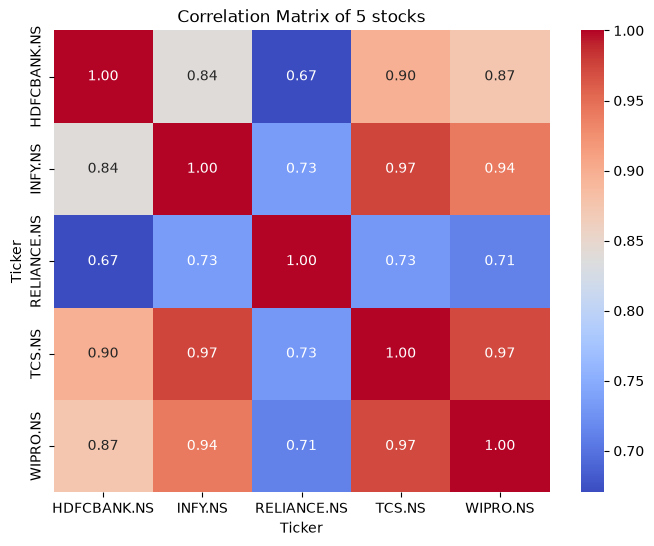

In [30]:
plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of 5 stocks')
plt.show()

## week 2 day 4